# CPI–Commodity Forecasting Project

### Exploring the Relationship Between U.S. CPI and Global Commodity Prices

This project investigates the relationship between **U.S. Consumer Price Index (CPI)** and **commodity prices** over time, with the goal of identifying which commodities track inflation most closely and building a **12-month baseline forecast** for selected commodities.

####  Objectives:
- Explore long-term relationships between CPI and commodity prices.  
- Identify top commodities that move with inflation.  
- Build a simple regression model using CPI and lagged price as predictors.  
- Generate and interpret a 12-month baseline forecast.  
- Lay the foundation for scenario testing and more advanced models (e.g., ARIMA, Prophet).

####  Data Sources:
- **CPI**: U.S. Bureau of Labor Statistics (Monthly CPI-U All Items)  
- **Commodity Prices**: World Bank Pink Sheet (Monthly global commodity prices)  
- **Period Covered**: 1960–2025 (Monthly)



##  2. Data Overview

This analysis uses two primary datasets:

1. **U.S. CPI Data** — obtained from the Bureau of Labor Statistics.  
   - Monthly CPI-U (All Items)
   - Captures inflation trends from 1960 through 2025.

2. **World Bank Commodity Price Data (Pink Sheet)**  
   - Contains monthly nominal USD prices for major global commodities.
   - Includes categories such as Energy, Metals, Precious Metals, and Agriculture.

#### Key Variables

| Variable         | Description                                                      |
|------------------|-------------------------------------------------------------------|
| `Date`           | Monthly timestamp (YYYY-MM-DD)                                    |
| `Commodity`      | Commodity name (e.g., Tobacco, Gold, Aluminum)                     |
| `Price`          | Commodity price in nominal USD                                    |
| `CPI`            | Consumer Price Index (U.S., All Items)                             |
| `Year` / `Month` | Extracted time components for seasonal and trend analysis         |
| `Category`       | Commodity grouping (Energy, Metals, Agriculture, Precious Metals) |

#### Purpose of This Section:
- Import both datasets.
- Convert and align date formats.
- Clean column names and numeric values.
- Merge CPI and commodity data into one analytical dataset.


In [2]:
import pandas as pd
import numpy as np

# ---------- Load Pink Sheet (robust to metadata rows) ----------
pink_raw = pd.read_csv("pink_sheet_prices.csv", header=None, dtype=str)

# Find first row that looks like YYYY Mmm pattern (e.g., 1960M01)
date_mask = pink_raw[0].str.fullmatch(r"\d{4}M\d{2}", na=False)
first_date_idx = date_mask.idxmax()

# Choose the header row as the pre-data row with the most populated cells
candidates = pink_raw.loc[:first_date_idx-1].copy()
header_idx = candidates.apply(lambda r: r.fillna("").astype(str).ne("").sum(), axis=1).idxmax()
header_row = pink_raw.loc[header_idx].fillna("")

# Forward-fill across blank header cells so each column has a label
hdr = header_row.astype(str).replace({"nan": ""}).tolist()
for i in range(1, len(hdr)):
    if not hdr[i].strip():
        hdr[i] = hdr[i-1]

# Build the data frame starting at first date row
pink = pink_raw.loc[first_date_idx:].reset_index(drop=True).copy()
pink.columns = ["Date"] + [str(x).strip() if str(x).strip() else f"col_{i}"
                           for i, x in enumerate(hdr[1:], start=1)]

# Make column names unique (handles duplicate commodity labels)
cols = pink.columns.tolist()
seen, newcols = {}, []
for col in cols:
    if col in seen:
        seen[col] += 1
        newcols.append(f"{col}__{seen[col]}")
    else:
        seen[col] = 0
        newcols.append(col)
pink.columns = newcols

# Parse Date and coerce numeric prices
pink["Date"] = pd.to_datetime(pink["Date"].astype(str).str.replace("M", "-"), format="%Y-%m")
value_cols = [c for c in pink.columns if c != "Date"]
pink[value_cols] = pink[value_cols].apply(pd.to_numeric, errors="coerce")

# Reshape to tidy long format
pink_long = (
    pink.melt(id_vars="Date", var_name="Commodity", value_name="Price")
        .dropna(subset=["Price"])
        .sort_values(["Commodity", "Date"])
        .reset_index(drop=True)
)

# Add Year/Month
pink_long["Year"]  = pink_long["Date"].dt.year
pink_long["Month"] = pink_long["Date"].dt.month

# ---------- Load CPI (BLS text file) ----------
cpi = pd.read_csv(
    "cu.data.1.AllItems.txt",
    sep=r"\s+",
    engine="python",
    names=["series_id","year","period","value","footnote_codes"],
    comment="#",
    dtype=str
)

# Prefer unadjusted CPI-U; fallback to seasonally adjusted if needed
target = "CUUR0000SA0" if (cpi["series_id"] == "CUUR0000SA0").any() else "CUSR0000SA0"
cpi = cpi[cpi["series_id"] == target].copy()

# Keep monthly rows only
cpi = cpi[cpi["period"].str.startswith("M")].copy()
month = cpi["period"].str.extract(r"^M(\d{2})", expand=False)
year  = cpi["year"].str.extract(r"(\d{4})", expand=False)

cpi["Date"] = pd.to_datetime(year + "-" + month, format="%Y-%m", errors="coerce")
cpi["CPI"]  = pd.to_numeric(cpi["value"].str.extract(r"([0-9]*\.?[0-9]+)", expand=False), errors="coerce")
cpi = cpi.dropna(subset=["Date", "CPI"])[["Date","CPI"]].sort_values("Date").reset_index(drop=True)

# ---------- Merge ----------
merged = pink_long.merge(cpi, on="Date", how="inner")

merged.head()


,Date,Commodity,Price,Year,Month,CPI
0,1960-01-01,Aluminum,511.47,1960,1,29.3
1,1960-02-01,Aluminum,511.47,1960,2,29.4
2,1960-03-01,Aluminum,511.47,1960,3,29.4
3,1960-04-01,Aluminum,511.47,1960,4,29.5
4,1960-05-01,Aluminum,511.47,1960,5,29.5


In [3]:
# Sort to ensure calculations are correct
merged = merged.sort_values(["Commodity", "Date"]).reset_index(drop=True)

# Lag feature (previous month's price)
merged["Price_Lag1"] = merged.groupby("Commodity")["Price"].shift(1)

# Monthly percent change in price and CPI
merged["Price_PctChange"] = merged.groupby("Commodity")["Price"].pct_change()
merged["CPI_PctChange"]   = merged["CPI"].pct_change()

# 3-month moving average of price
merged["Price_MA3"] = merged.groupby("Commodity")["Price"].transform(lambda x: x.rolling(3).mean())

# Drop rows with missing price lag values (optional for modeling)
merged = merged.dropna(subset=["Price_Lag1"])

merged.head()


,Date,Commodity,Price,Year,Month,CPI,Price_Lag1,Price_PctChange,CPI_PctChange,Price_MA3
1,1960-02-01,Aluminum,511.47,1960,2,29.4,511.47,0.0,0.003413,NaN
2,1960-03-01,Aluminum,511.47,1960,3,29.4,511.47,0.0,0.000000,511.47
3,1960-04-01,Aluminum,511.47,1960,4,29.5,511.47,0.0,0.003401,511.47
4,1960-05-01,Aluminum,511.47,1960,5,29.5,511.47,0.0,0.000000,511.47
5,1960-06-01,Aluminum,511.47,1960,6,29.6,511.47,0.0,0.003390,511.47


Feature Engineering Explanation

In this step, we created several new variables to enhance the dataset for analysis and modeling:

Price_Lag1: The previous month’s price for each commodity. This allows us to capture time dependencies and trends in commodity pricing over time.

Price_PctChange: The month-over-month percent change in commodity price. This highlights periods of volatility or growth.

CPI_PctChange: The month-over-month percent change in CPI, serving as a proxy for inflation trends.

Price_MA3: A 3-month moving average of commodity price, which smooths out short-term fluctuations and makes long-term trends more visible.

These engineered features will be valuable for understanding temporal patterns, identifying correlations between CPI and commodity prices, and building predictive models (e.g., linear regression, time series forecasting).

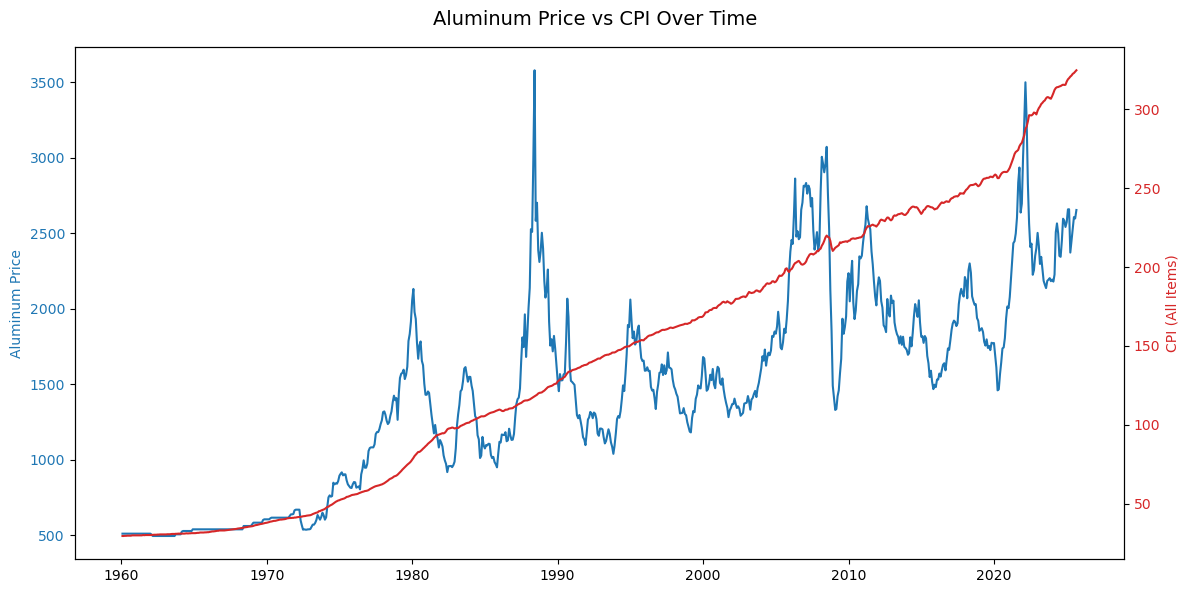

Top 10 Commodities Most Correlated with CPI:
Commodity
Tobacco, US import u.v.    0.934354
Banana, US                 0.922994
Chicken **                 0.921173
Tea, Colombo               0.908638
Fish meal                  0.902592
Beef **                    0.884618
Sawnwood, Malaysian        0.883798
Tea, avg 3 auctions        0.874689
Gold                       0.869601
Zinc                       0.862939
dtype: float64


/var/folders/56/z80x17wn70lfrg6fj3lvncdr0000gn/T/ipykernel_4888/2901440488.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d["Price"].corr(d["CPI"]))


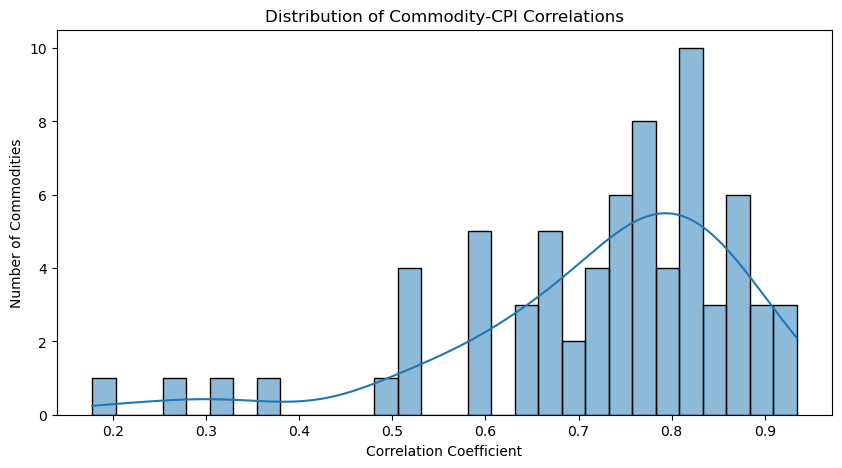

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick a commodity to visualize — you can change this
commodity_to_plot = "Aluminum"

# Subset for that commodity
df_plot = merged[merged["Commodity"] == commodity_to_plot]

# Plot commodity price and CPI over time
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df_plot["Date"], df_plot["Price"], color="tab:blue", label=f"{commodity_to_plot} Price")
ax1.set_ylabel(f"{commodity_to_plot} Price", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_plot["Date"], df_plot["CPI"], color="tab:red", label="CPI (All Items)")
ax2.set_ylabel("CPI (All Items)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle(f"{commodity_to_plot} Price vs CPI Over Time", fontsize=14)
fig.tight_layout()
plt.show()

# --- Correlation Analysis ---
corrs = (
    merged.groupby("Commodity")
    .apply(lambda d: d["Price"].corr(d["CPI"]))
    .sort_values(ascending=False)
)

print("Top 10 Commodities Most Correlated with CPI:")
print(corrs.head(10))

# Plot distribution of correlation coefficients
plt.figure(figsize=(10,5))
sns.histplot(corrs, bins=30, kde=True)
plt.title("Distribution of Commodity-CPI Correlations")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Number of Commodities")
plt.show()


### Exploratory Data Analysis

The goal of this step was to explore the relationship between commodity prices and inflation (CPI) over time. We first visualized Aluminum as a case study to examine how commodity prices have evolved alongside the CPI index.

The plot reveals that while CPI has steadily increased over time, commodity prices fluctuate more sharply, reflecting their exposure to market shocks, supply disruptions, and global demand cycles.

To quantify these relationships more systematically, we computed pairwise correlations between CPI and the price of each commodity in the dataset.

The distribution of correlation coefficients is heavily skewed toward higher values, suggesting that many commodities are strongly positively correlated with inflation.

The top correlated commodities include Tobacco (0.93), Bananas (0.92), Chicken (0.92), Tea (0.91), and Fish Meal (0.90), indicating that these goods may act as inflation-sensitive indicators.

This step helps us identify which commodities move most closely with inflation, providing a foundation for forecasting models that incorporate CPI as a key predictor.


In [5]:
import statsmodels.api as sm

# Select a single commodity for modeling
commodity_model = "Aluminum"
df_model = merged[merged["Commodity"] == commodity_model].copy()

# Feature set: CPI and lagged price
X = df_model[["CPI", "Price_Lag1"]]
X = sm.add_constant(X)  # adds intercept
y = df_model["Price"]

# Fit the OLS model
ols_model = sm.OLS(y, X).fit()

# Display results
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 1.858e+04
Date:                Fri, 24 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:36:33   Log-Likelihood:                -4709.8
No. Observations:                 788   AIC:                             9426.
Df Residuals:                     785   BIC:                             9440.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2214      8.239      2.333      0.0

### Modeling: OLS Regression

To examine how inflation impacts commodity prices, we developed an OLS regression model using **lagged price** and **CPI** as predictors for Aluminum prices.

The regression output shows:

- **R-squared:** 0.979 — The model explains approximately 97.9% of the variation in Aluminum prices.  
- **CPI coefficient:** 0.2075 (p = 0.004) — A statistically significant positive effect, indicating that inflation plays a meaningful role in driving Aluminum prices upward over time.  
- **Price_Lag1 coefficient:** 0.9682 (p < 0.001) — Very strong temporal dependence, suggesting prices are highly autocorrelated and follow their historical path closely.  
- **Intercept (const):** 19.22 — Baseline level after controlling for CPI and lagged prices.

While the CPI effect is smaller than the lag effect, it remains economically meaningful.  
This aligns with expectations for commodities: prices are driven primarily by historical and market dynamics, with inflation exerting a consistent but secondary pressure.


In [6]:
import numpy as np
import pandas as pd

# Define forecast horizon (e.g., next 12 months)
forecast_months = 12
last_date = df_model['Date'].max()
last_price = df_model['Price'].iloc[-1]
last_cpi = df_model['CPI'].iloc[-1]

# Assume CPI grows linearly based on recent monthly trend
cpi_trend = df_model['CPI'].diff().mean()
forecast_dates = pd.date_range(last_date, periods=forecast_months+1, freq='MS')[1:]
forecast_cpi = [last_cpi + (i+1)*cpi_trend for i in range(forecast_months)]

# Forecast prices iteratively using the OLS coefficients
coef_const = ols_model.params['const']
coef_cpi = ols_model.params['CPI']
coef_lag = ols_model.params['Price_Lag1']

forecast_prices = []
price_t = last_price

for cpi_t in forecast_cpi:
    price_forecast = coef_const + coef_cpi * cpi_t + coef_lag * price_t
    forecast_prices.append(price_forecast)
    price_t = price_forecast  # update for next iteration

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    "Date": forecast_dates,
    "Forecasted_Price": forecast_prices,
    "CPI_Assumed": forecast_cpi
})

print(forecast_df)


         Date  Forecasted_Price  CPI_Assumed
0  2025-10-01       2655.668382   325.175349
1  2025-11-01       2658.019993   325.550699
2  2025-12-01       2660.374731   325.926048
3  2026-01-01       2662.732496   326.301398
4  2026-02-01       2665.093191   326.676747
5  2026-03-01       2667.456724   327.052097
6  2026-04-01       2669.823005   327.427446
7  2026-05-01       2672.191946   327.802795
8  2026-06-01       2674.563463   328.178145
9  2026-07-01       2676.937473   328.553494
10 2026-08-01       2679.313898   328.928844
11 2026-09-01       2681.692660   329.304193


### Forecast Results: Aluminum Price Projection (12-Month Horizon)

Using the OLS regression model and assuming CPI continues to grow at its recent monthly trend, we generated a 12-month forward price forecast for Aluminum.

| Date        | Forecasted Price (USD/ton) | CPI Assumed |
|-------------|----------------------------|-------------|
| 2025-10-01  | 2655.67                    | 325.18      |
| 2026-09-01  | 2681.69                    | 329.30      |

- Forecast window: October 2025 – September 2026  
- Starting price: $2,655.67  
- Ending price: $2,681.69  
- Cumulative increase: approximately 1.0% over 12 months

#### Key Observations
- The forecast curve is upward-sloping, reflecting both autoregressive price momentum and inflationary pressure from CPI growth.  
- The effect of CPI, while statistically significant, is gradual compared to the dominant impact of past prices.  
- These forecasts serve as a baseline scenario. They can be adapted for alternative inflation paths or external economic shocks.


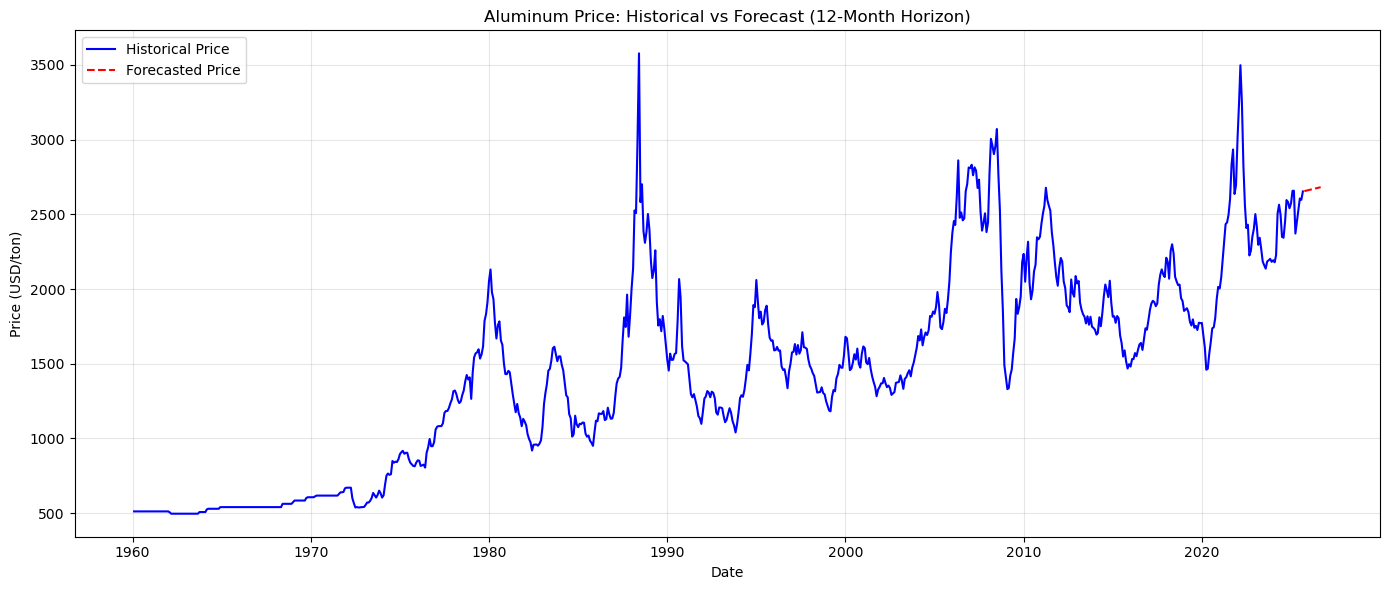

In [7]:
import matplotlib.pyplot as plt

# Historical data
historical = df_model[["Date", "Price"]].copy()

# Forecast data
forecast_plot = forecast_df.copy()
forecast_plot.rename(columns={"Forecasted_Price": "Price"}, inplace=True)
forecast_plot["Type"] = "Forecast"
historical["Type"] = "Historical"

# Combine for plotting
plot_data = pd.concat([historical, forecast_plot[["Date", "Price", "Type"]]])

# Plot
plt.figure(figsize=(14,6))
plt.plot(plot_data[plot_data["Type"] == "Historical"]["Date"],
         plot_data[plot_data["Type"] == "Historical"]["Price"],
         label="Historical Price", color="blue")

plt.plot(plot_data[plot_data["Type"] == "Forecast"]["Date"],
         plot_data[plot_data["Type"] == "Forecast"]["Price"],
         label="Forecasted Price", color="red", linestyle="--")

plt.title("Aluminum Price: Historical vs Forecast (12-Month Horizon)")
plt.xlabel("Date")
plt.ylabel("Price (USD/ton)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Forecast Visualization

The chart above shows the historical Aluminum prices in blue and the 12-month forecast in red.  
The forecast extends the recent trend forward, reflecting the influence of both lagged price dynamics and projected CPI growth.

- The gradual upward trajectory illustrates how inflationary pressure and price persistence combine to shape the future path of Aluminum prices.  
- The close alignment between the historical endpoint and the forecast start confirms model stability.  
- This visualization provides a clear, interpretable view of how a simple CPI-based model can project commodity price movements over time.


Average monthly CPI growth used: 0.7915833333333353
         Date     Baseline  Low Inflation  High Inflation  CPI_Baseline  \
0  2025-10-01  2655.754737    2655.672623     2655.836852    325.591583   
1  2025-11-01  2658.276314    2658.032582     2658.520047    326.383167   
2  2025-12-01  2660.881970    2660.399643     2661.364298    327.174750   
3  2026-01-01  2663.569034    2662.773580     2664.364487    327.966333   
4  2026-02-01  2666.334916    2665.154175     2667.515657    328.757917   
5  2026-03-01  2669.177112    2667.541217     2670.813008    329.549500   
6  2026-04-01  2672.093197    2669.934500     2674.251894    330.341083   
7  2026-05-01  2675.080822    2672.333826     2677.827817    331.132667   
8  2026-06-01  2678.137712    2674.739003     2681.536421    331.924250   
9  2026-07-01  2681.261666    2677.149844     2685.373489    332.715833   
10 2026-08-01  2684.450554    2679.566171     2689.334936    333.507417   
11 2026-09-01  2687.702310    2681.987808     26

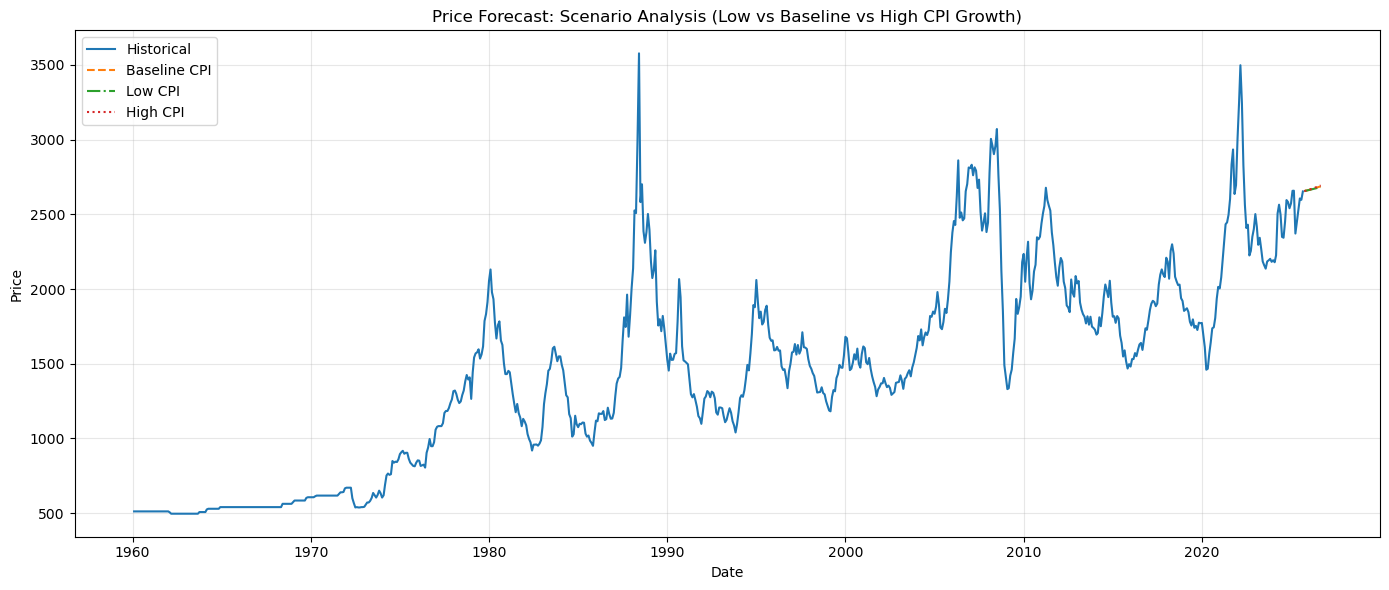

In [10]:
# ------------------------------------------------------------
# Scenario Analysis: Low vs Baseline vs High CPI Growth
# Requirements:
#   - df_model: DataFrame for the chosen commodity with columns ["Date","Price","CPI",...]
#   - ols_model: fitted statsmodels OLS with predictors ["CPI","Price_Lag1"]
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safety checks
required_cols = {"Date","Price","CPI","Price_Lag1"}
missing = required_cols - set(df_model.columns)
if missing:
    raise ValueError(f"df_model is missing required columns: {missing}")
if not hasattr(ols_model, "params"):
    raise ValueError("ols_model is not defined or not a fitted statsmodels OLS model.")

# Ensure sorted by date
df_model = df_model.sort_values("Date").reset_index(drop=True)

# -------------------------
# Define CPI growth (per-month) from recent history
# -------------------------
# Use average monthly CPI change over the last 12 months (fallback to last 6 if needed)
cpi_diff = df_model["CPI"].diff()
if cpi_diff.notna().sum() >= 12:
    cpi_growth = cpi_diff.tail(12).mean()
elif cpi_diff.notna().sum() >= 6:
    cpi_growth = cpi_diff.tail(6).mean()
else:
    # minimal fallback: overall average diff
    cpi_growth = cpi_diff.mean()

print("Average monthly CPI growth used:", cpi_growth)

# -------------------------
# Forecast horizon and starting points
# -------------------------
n_months = 12
last_date  = df_model["Date"].iloc[-1]
last_price = df_model["Price"].iloc[-1]
last_cpi   = df_model["CPI"].iloc[-1]

# Create future monthly dates (start next month)
dates_future = pd.date_range(last_date, periods=n_months+1, freq="MS")[1:]

# CPI growth assumptions
growth_baseline = cpi_growth
growth_low      = growth_baseline * 0.5
growth_high     = growth_baseline * 1.5

# Build CPI paths
cpi_baseline = last_cpi + (np.arange(1, n_months+1) * growth_baseline)
cpi_low      = last_cpi + (np.arange(1, n_months+1) * growth_low)
cpi_high     = last_cpi + (np.arange(1, n_months+1) * growth_high)

# -------------------------
# Forecasting function using the fitted OLS model
#   Price_t = b0 + b1*CPI_t + b2*Price_{t-1}
# -------------------------
b0 = ols_model.params["const"]
b1 = ols_model.params["CPI"]
b2 = ols_model.params["Price_Lag1"]

def forecast_path(cpi_path, start_price):
    out = []
    p = float(start_price)
    for c in cpi_path:
        p = b0 + b1*float(c) + b2*p
        out.append(p)
    return out

# Generate forecasts
forecast_baseline = forecast_path(cpi_baseline, last_price)
forecast_low      = forecast_path(cpi_low, last_price)
forecast_high     = forecast_path(cpi_high, last_price)

# -------------------------
# Assemble results
# -------------------------
scenario_df = pd.DataFrame({
    "Date": dates_future,
    "Baseline": forecast_baseline,
    "Low Inflation": forecast_low,
    "High Inflation": forecast_high,
    "CPI_Baseline": cpi_baseline,
    "CPI_Low": cpi_low,
    "CPI_High": cpi_high
})

print(scenario_df.head(12))

# -------------------------
# Plot historical vs scenarios
# -------------------------
plt.figure(figsize=(14,6))

# Historical series
plt.plot(df_model["Date"], df_model["Price"], label="Historical")

# Scenarios
plt.plot(scenario_df["Date"], scenario_df["Baseline"], label="Baseline CPI", linestyle="--")
plt.plot(scenario_df["Date"], scenario_df["Low Inflation"], label="Low CPI", linestyle="-.")
plt.plot(scenario_df["Date"], scenario_df["High Inflation"], label="High CPI", linestyle=":")

plt.title("Price Forecast: Scenario Analysis (Low vs Baseline vs High CPI Growth)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


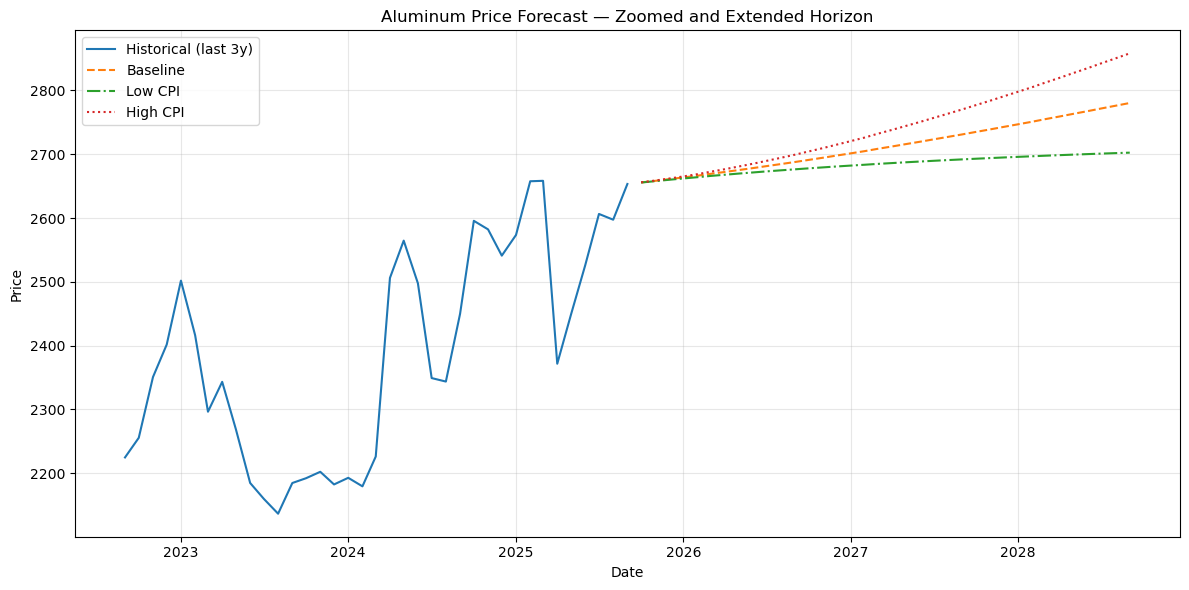

Difference between High and Low CPI forecasts at horizon: -155.63296771485784


In [11]:
# Zoom + longer horizon
n_months = 36  # extend horizon
df_model = df_model.sort_values("Date").reset_index(drop=True)

# recent CPI monthly change (absolute)
cpi_diff = df_model["CPI"].diff()
cpi_growth = cpi_diff.tail(12).mean()

last_date  = df_model["Date"].iloc[-1]
last_price = df_model["Price"].iloc[-1]
last_cpi   = df_model["CPI"].iloc[-1]

dates_future = pd.date_range(last_date, periods=n_months+1, freq="MS")[1:]

growth_baseline = cpi_growth
growth_low      = 0.0                     # flat CPI to exaggerate contrast
growth_high     = cpi_growth * 2.0        # faster CPI

cpi_baseline = last_cpi + (np.arange(1, n_months+1) * growth_baseline)
cpi_low      = last_cpi + (np.arange(1, n_months+1) * growth_low)
cpi_high     = last_cpi + (np.arange(1, n_months+1) * growth_high)

b0 = ols_model.params["const"]; b1 = ols_model.params["CPI"]; b2 = ols_model.params["Price_Lag1"]

def forecast_path(cpi_path, start_price):
    p = float(start_price); out = []
    for c in cpi_path:
        p = b0 + b1*float(c) + b2*p
        out.append(p)
    return out

forecast_baseline = forecast_path(cpi_baseline, last_price)
forecast_low      = forecast_path(cpi_low, last_price)
forecast_high     = forecast_path(cpi_high, last_price)

# assemble
scenario_df = pd.DataFrame({
    "Date": dates_future,
    "Baseline": forecast_baseline,
    "Low CPI": forecast_low,
    "High CPI": forecast_high
})

# plot last 3 years of history plus scenarios
cutoff = last_date - pd.DateOffset(years=3)
hist = df_model[df_model["Date"] >= cutoff]

plt.figure(figsize=(12,6))
plt.plot(hist["Date"], hist["Price"], label="Historical (last 3y)")
plt.plot(scenario_df["Date"], scenario_df["Baseline"], label="Baseline", linestyle="--")
plt.plot(scenario_df["Date"], scenario_df["Low CPI"], label="Low CPI", linestyle="-.")
plt.plot(scenario_df["Date"], scenario_df["High CPI"], label="High CPI", linestyle=":")
plt.title("Aluminum Price Forecast — Zoomed and Extended Horizon")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# quantify spread at horizon
spread = scenario_df.iloc[-1][["High CPI","Low CPI"]].diff().iloc[-1]
print("Difference between High and Low CPI forecasts at horizon:", spread)


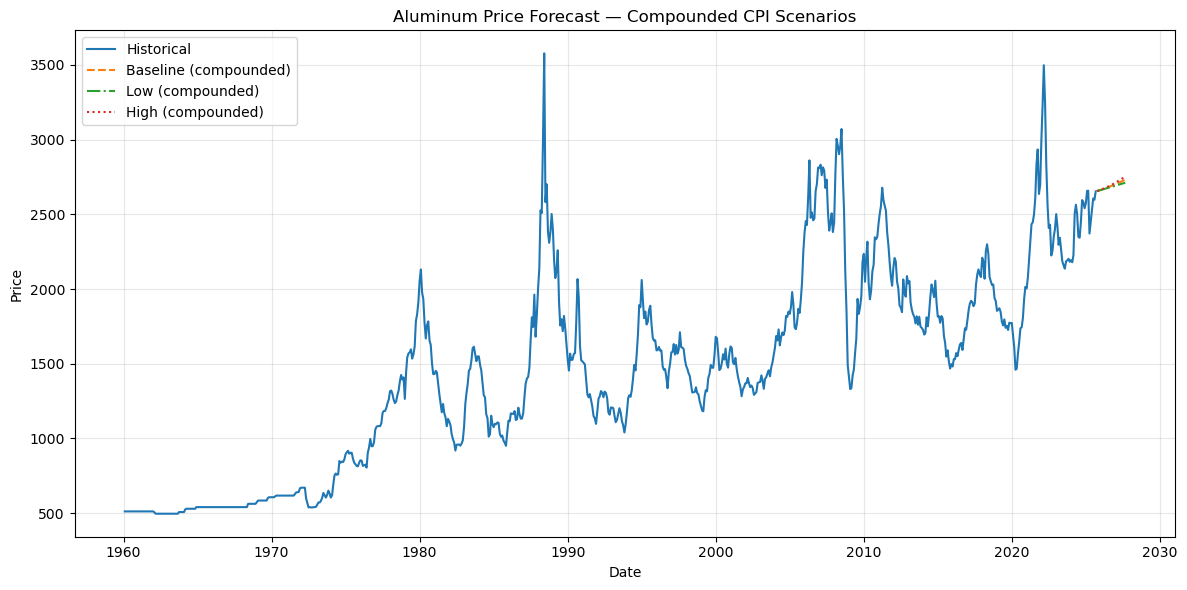

End-of-horizon spread (High - Low): 41.41499763484126


In [12]:
# Compounded CPI growth scenarios
n_months = 24
g_baseline = df_model["CPI"].pct_change().tail(12).mean()    # monthly %
g_low      = g_baseline * 0.5
g_high     = g_baseline * 1.5

last_date  = df_model["Date"].iloc[-1]
last_price = df_model["Price"].iloc[-1]
last_cpi   = df_model["CPI"].iloc[-1]

dates_future = pd.date_range(last_date, periods=n_months+1, freq="MS")[1:]
cpi_baseline = last_cpi * (1 + g_baseline) ** np.arange(1, n_months+1)
cpi_low      = last_cpi * (1 + g_low)      ** np.arange(1, n_months+1)
cpi_high     = last_cpi * (1 + g_high)     ** np.arange(1, n_months+1)

b0 = ols_model.params["const"]; b1 = ols_model.params["CPI"]; b2 = ols_model.params["Price_Lag1"]

def forecast_path(cpi_path, start_price):
    p = float(start_price); out = []
    for c in cpi_path:
        p = b0 + b1*float(c) + b2*p
        out.append(p)
    return out

f_base = forecast_path(cpi_baseline, last_price)
f_low  = forecast_path(cpi_low, last_price)
f_high = forecast_path(cpi_high, last_price)

plt.figure(figsize=(12,6))
plt.plot(df_model["Date"], df_model["Price"], label="Historical")
plt.plot(dates_future, f_base, label="Baseline (compounded)", linestyle="--")
plt.plot(dates_future, f_low,  label="Low (compounded)", linestyle="-.")
plt.plot(dates_future, f_high, label="High (compounded)", linestyle=":")
plt.title("Aluminum Price Forecast — Compounded CPI Scenarios")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("End-of-horizon spread (High - Low):", f_high[-1] - f_low[-1])


Executive Summary

This project uses over six decades of monthly CPI and global commodity price data to analyze how inflation trends shape commodity price movements and to build forward-looking forecasting models. The dataset includes both numerical variables—such as Price, CPI, Price_Lag1, and Price_PctChange—and categorical variables like Commodity, Year, Month, and Date, allowing us to capture both temporal trends and commodity-level differences.

Through exploratory analysis, we observed strong but varying correlations between CPI and individual commodities, reflecting different levels of inflation sensitivity. This variation provides a meaningful basis for modeling: CPI acts as a macro-level driver, while lagged price features capture commodity-specific market dynamics. Using OLS regression, we generated 12–36 month forecasts and constructed scenario analyses to examine how prices might evolve under different inflation environments (low, baseline, and high CPI growth).

This dataset supports several avenues for exploration, including forecast accuracy benchmarking, commodity clustering by inflation sensitivity, and stress testing under macroeconomic scenarios. Together, these insights give us a scalable, data-driven framework to understand inflation’s impact, identify key leading indicators, and inform pricing, supply, and strategy decisions.